In [ ]:
!pip install Sastrawi nltk wordcloud seaborn scikit-learn scipy joblib langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.9 MB/s eta 0:00:00


In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import pickle
import random
from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score
)

# NLP
from langdetect import detect, LangDetectException
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download NLTK resources
for res in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{res}")
    except LookupError:
        try:
            nltk.download(res, quiet=True)
        except Exception:
            pass

# Suppress warnings
warnings.filterwarnings("ignore")
tqdm.pandas()

print("✓ Semua library berhasil di-import\n")

✓ Semua library berhasil di-import



In [ ]:
# Set random seed untuk reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving A All Data.csv to A All Data.csv


In [ ]:
# File paths
INPUT_PATH = "A All Data.csv"
CACHE_PREP = "cache_preprocessed_final.csv"
LEXICON_POS_CACHE = "lexicon_pos.tsv"
LEXICON_NEG_CACHE = "lexicon_neg.tsv"

In [ ]:
# Parameters
N_FOLDS = 5
TEST_SIZE = 0.2
THRESHOLD_SENTIMENT = 1.0

In [ ]:
# Matplotlib configuration
plt.style.use("default")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [ ]:
# Load dataset
try:
    df = pd.read_csv(INPUT_PATH)
    print(f"✓ Dataset berhasil dimuat")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}\n")
except FileNotFoundError:
    print(f"❌ File {INPUT_PATH} tidak ditemukan!")
    raise

# Validate required columns
required_cols = ["text", "stars", "title"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"❌ Kolom yang hilang: {missing_cols}")
    raise ValueError(f"Dataset harus memiliki kolom: {required_cols}")

print(f"📊 STATISTIK AWAL DATASET:")
print(f"  Jumlah baris        : {len(df):,}")
print(f"  Jumlah kolom        : {df.shape[1]}")
print(f"  Missing values      : {df.isna().sum().sum()}")
print(f"  Duplikat            : {df.duplicated().sum()}")
print(f"  Destinasi unik      : {df['title'].nunique()}\n")


✓ Dataset berhasil dimuat
  Shape: (30071, 6)
  Columns: ['title', 'url', 'stars', 'name', 'reviewUrl', 'text']

📊 STATISTIK AWAL DATASET:
  Jumlah baris        : 30,071
  Jumlah kolom        : 6
  Missing values      : 13023
  Duplikat            : 0
  Destinasi unik      : 323



In [ ]:
# Text length analysis
df["review_length"] = df["text"].str.len()
df["review_words"] = df["text"].str.split().str.len()

print(f"\n📊 PANJANG ULASAN (KARAKTER):")
print(f"  Mean   : {df['review_length'].mean():.0f}")
print(f"  Median : {df['review_length'].median():.0f}")
print(f"  Min    : {df['review_length'].min()}")
print(f"  Max    : {df['review_length'].max()}")

print(f"\n📊 JUMLAH KATA PER ULASAN:")
print(f"  Mean   : {df['review_words'].mean():.1f}")
print(f"  Median : {df['review_words'].median():.0f}")
print(f"  Min    : {df['review_words'].min()}")
print(f"  Max    : {df['review_words'].max()}")


📊 PANJANG ULASAN (KARAKTER):
  Mean   : 146
  Median : 70
  Min    : 1.0
  Max    : 3829.0

📊 JUMLAH KATA PER ULASAN:
  Mean   : 22.3
  Median : 11
  Min    : 1.0
  Max    : 583.0


In [ ]:
# Top destinations
print(f"\n📊 TOP 10 DESTINASI TERPOPULER:")
top_dests = df["title"].value_counts().head(10)
for i, (dest, count) in enumerate(top_dests.items(), 1):
    pct = (count / len(df)) * 100
    print(f"  {i:2d}. {dest[:40]:40s} : {count:5,} ({pct:5.1f}%)")


📊 TOP 10 DESTINASI TERPOPULER:
   1. Wunung Giriselokondo                     :   100 (  0.3%)
   2. Affandi Museum                           :   100 (  0.3%)
   3. Agrowisata Turi                          :   100 (  0.3%)
   4. Waterboom Jogja                          :   100 (  0.3%)
   5. Waterbyur                                :   100 (  0.3%)
   6. Wana Delima Orchard                      :   100 (  0.3%)
   7. Waduk Sermo                              :   100 (  0.3%)
   8. Turgo Plawangan                          :   100 (  0.3%)
   9. Tlogo Muncar                             :   100 (  0.3%)
  10. The World Landmark Merapi Park           :   100 (  0.3%)


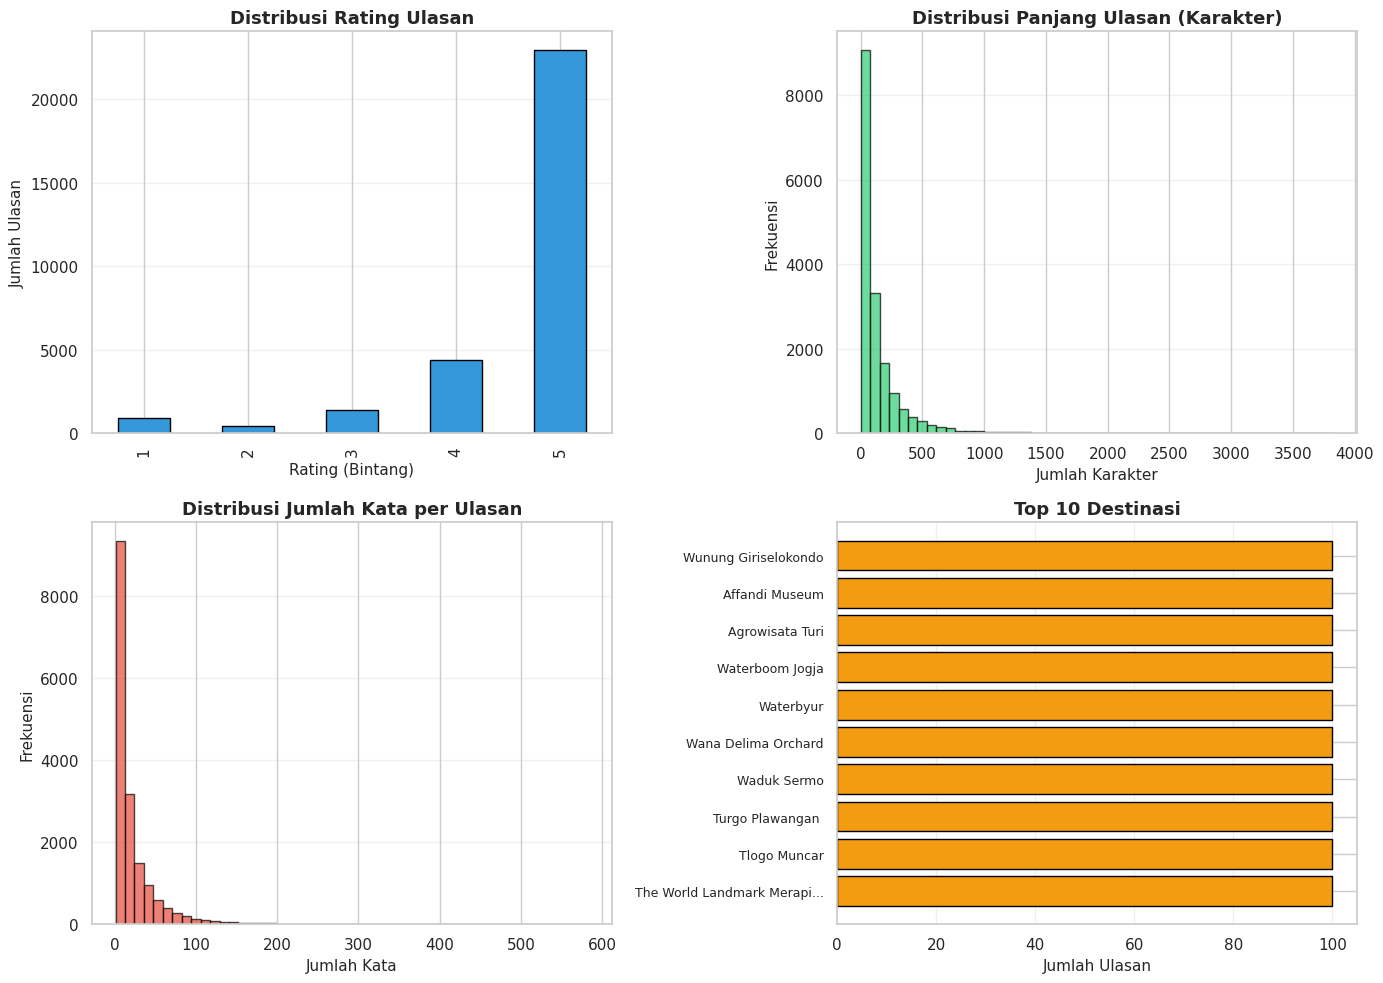


✓ EDA visualization tersimpan: 00_eda_dataset_overview.png


In [ ]:
# Visualisasi EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
ax1 = axes[0, 0]
df["stars"].value_counts().sort_index().plot(kind="bar", ax=ax1, color="#3498db", edgecolor="black")
ax1.set_title("Distribusi Rating Ulasan", fontweight='bold')
ax1.set_xlabel("Rating (Bintang)")
ax1.set_ylabel("Jumlah Ulasan")
ax1.grid(True, alpha=0.3, axis='y')

# Review length
ax2 = axes[0, 1]
ax2.hist(df["review_length"], bins=50, color="#2ecc71", edgecolor="black", alpha=0.7)
ax2.set_title("Distribusi Panjang Ulasan (Karakter)", fontweight='bold')
ax2.set_xlabel("Jumlah Karakter")
ax2.set_ylabel("Frekuensi")
ax2.grid(True, alpha=0.3, axis='y')

# Words per review
ax3 = axes[1, 0]
ax3.hist(df["review_words"], bins=50, color="#e74c3c", edgecolor="black", alpha=0.7)
ax3.set_title("Distribusi Jumlah Kata per Ulasan", fontweight='bold')
ax3.set_xlabel("Jumlah Kata")
ax3.set_ylabel("Frekuensi")
ax3.grid(True, alpha=0.3, axis='y')

# Top destinations
ax4 = axes[1, 1]
top_10_dest = df["title"].value_counts().head(10)
ax4.barh(range(len(top_10_dest)), top_10_dest.values, color="#f39c12", edgecolor="black")
ax4.set_yticks(range(len(top_10_dest)))
ax4.set_yticklabels([d[:25] + "..." if len(d) > 25 else d for d in top_10_dest.index], fontsize=9)
ax4.set_title("Top 10 Destinasi", fontweight='bold')
ax4.set_xlabel("Jumlah Ulasan")
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig("00_eda_dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ EDA visualization tersimpan: 00_eda_dataset_overview.png")

In [ ]:
print("\n" + "="*80)
print("SECTION 4: DATA CLEANING")
print("="*80)

# Remove missing values
df = df.dropna(subset=["text", "stars", "title"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].copy()

# Remove duplicates
before_dup = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
after_dup = len(df)

print(f"\n✓ Data cleaning selesai")
print(f"  Duplikat dihapus: {before_dup - after_dup}")
print(f"  Total data: {len(df):,}\n")


SECTION 4: DATA CLEANING

✓ Data cleaning selesai
  Duplikat dihapus: 1139
  Total data: 15,909



In [ ]:
print("="*80)
print("SECTION 5: LANGUAGE DETECTION & FILTERING")
print("="*80)

def detect_lang(text):
    """Detect language of text"""
    text = str(text)
    if len(text.split()) < 3:
        return "id"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

print("\n🔄 Mendeteksi bahasa ulasan...\n")

n_before = len(df)
df["lang"] = df["text"].progress_apply(detect_lang)
lang_dist = df["lang"].value_counts()

print(f"📊 DISTRIBUSI BAHASA:")
for lang, count in lang_dist.items():
    pct = (count / len(df)) * 100
    print(f"  {lang:15s} : {count:6,} ({pct:5.1f}%)")

# Filter hanya Bahasa Indonesia
df = df[df["lang"] == "id"].reset_index(drop=True)
n_after = len(df)
removed = n_before - n_after

print(f"\n✓ Filter Bahasa Indonesia selesai")
print(f"  Data sebelum: {n_before:,}")
print(f"  Data dihapus: {removed:,} ({(removed/n_before)*100:.1f}%)")
print(f"  Data sekarang: {n_after:,}\n")

SECTION 5: LANGUAGE DETECTION & FILTERING

🔄 Mendeteksi bahasa ulasan...



100%|██████████| 15909/15909 [00:46<00:00, 341.91it/s]

📊 DISTRIBUSI BAHASA:
  id              : 14,401 ( 90.5%)
  en              :    894 (  5.6%)
  tl              :    179 (  1.1%)
  de              :     51 (  0.3%)
  nl              :     32 (  0.2%)
  fr              :     31 (  0.2%)
  et              :     30 (  0.2%)
  af              :     26 (  0.2%)
  so              :     25 (  0.2%)
  no              :     24 (  0.2%)
  sw              :     24 (  0.2%)
  ro              :     21 (  0.1%)
  fi              :     14 (  0.1%)
  es              :     14 (  0.1%)
  lt              :     14 (  0.1%)
  ca              :     13 (  0.1%)
  ko              :     12 (  0.1%)
  it              :     11 (  0.1%)
  hr              :      9 (  0.1%)
  da              :      8 (  0.1%)
  ru              :      8 (  0.1%)
  sl              :      8 (  0.1%)
  tr              :      7 (  0.0%)
  hu              :      7 (  0.0%)
  ja              :      6 (  0.0%)
  pl              :      6 (  0.0%)
  unknown         :      5 (  0.0%)
  ar   

In [ ]:
print("="*80)
print("SECTION 6: TEXT PREPROCESSING")
print("="*80)

# Slang dictionary
SLANG_DICT = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "nggak": "tidak",
    "bgt": "banget", "bgtt": "banget", "byk": "banyak", "dgn": "dengan",
    "yg": "yang", "utk": "untuk", "krn": "karena", "jd": "jadi",
    "jgn": "jangan", "mantul": "mantap", "recomended": "rekomendasi",
    "recommended": "rekomendasi", "worthit": "sepadan", "udah": "sudah",
    "tp": "tapi", "dr": "dari", "kalo": "kalau", "oke": "baik",
    "okey": "baik", "bnyk": "banyak", "sgt": "sangat", "kece": "bagus",
    "bgs": "bagus", "bgus": "bagus", "mantep": "mantap", "rame": "ramai",
}

# Important words (keep these in preprocessing)
IMPORTANT_WORDS = {
    "tidak", "bukan", "tanpa", "kurang", "belum", "jangan",
    "sangat", "amat", "sekali", "banget", "terlalu", "paling",
    "cukup", "agak", "lumayan", "lebih", "masih"
}

# Initialize NLP tools
sw_factory = StopWordRemoverFactory()
stopwords_list = set(sw_factory.get_stop_words())
stopwords_list.update(["yg", "aja", "nih", "nya", "deh", "kok", "dong", "sih", "kan",
                       "ya", "loh", "lho", "nah", "eh", "wkwk", "wkwkwk"])
stopwords_list = stopwords_list - IMPORTANT_WORDS

stemmer = StemmerFactory().create_stemmer()

print(f"✓ NLP tools initialized")
print(f"  Stopwords: {len(stopwords_list)}\n")

# Preprocessing pipeline
def clean_text(text):
    """Step 1: Basic cleaning"""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_tokens(tokens):
    """Step 2: Normalize slang"""
    return [SLANG_DICT.get(t, t) for t in tokens]

def preprocess_pipeline(text):
    """Full preprocessing pipeline"""
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = normalize_tokens(tokens)
    tokens = [re.sub(r"\d+", "", t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    tokens = [t for t in tokens if t not in stopwords_list]
    stemmed_text = stemmer.stem(" ".join(tokens))
    return stemmed_text

# Apply preprocessing
if "clean_text" not in df.columns:
    print("🔄 Menjalankan text preprocessing...\n")
    df["clean_text"] = df["text"].progress_apply(preprocess_pipeline)
    df.to_csv(CACHE_PREP, index=False)
else:
    print("✓ Menggunakan clean_text yang sudah ada\n")

# Remove empty documents
before_empty = len(df)
df = df[df["clean_text"].astype(str).str.len() > 0].reset_index(drop=True)
after_empty = len(df)

print(f"✓ Preprocessing selesai")
print(f"  Dokumen kosong dihapus: {before_empty - after_empty}")
print(f"  Total dokumen: {len(df):,}\n")

# Preview
print("📝 CONTOH TEXT SEBELUM & SESUDAH PREPROCESSING:\n")
preview_samples = df[["text", "clean_text"]].sample(5, random_state=42)
for idx, (orig, clean) in enumerate(zip(preview_samples["text"], preview_samples["clean_text"]), 1):
    print(f"Sampel {idx}:")
    print(f"  Original: {orig[:70]}...")
    print(f"  Cleaned:  {clean[:70]}...")
    print()

SECTION 6: TEXT PREPROCESSING
✓ NLP tools initialized
  Stopwords: 132

✓ Menggunakan clean_text yang sudah ada

✓ Preprocessing selesai
  Dokumen kosong dihapus: 0
  Total dokumen: 14,314

📝 CONTOH TEXT SEBELUM & SESUDAH PREPROCESSING:

Sampel 1:
  Original: Museum Batik Yogyakarta memberikan pengetahuan ttg batik, baik batik k...
  Cleaned:  museum batik yogyakarta beri tahu ttg batik baik batik khas yogyakarta...

Sampel 2:
  Original: Tempatnya cocok buat pelajar, mahasiswa, dan masyarakat untuk belajar ...
  Cleaned:  tempat cocok buat ajar mahasiswa masyarakat ajar mangrove hutan mangro...

Sampel 3:
  Original: -Kamar lumayan nyaman, kasurnya empuk selimutnya juga tebel. Ada meja ...
  Cleaned:  kamar lumayan nyaman kasur empuk selimut tebel meja sama cermin kemari...

Sampel 4:
  Original: Tempat nya lumayan luas,nyaman juga.
Tapi sarannya,kalau kesini antara...
  Cleaned:  tempat lumayan luas nyaman saran kalau kesini pagi sore biar tidak ter...

Sampel 5:
  Original: Pengalam

In [ ]:
# Custom sentiment lexicon (domain-specific)
CUSTOM_POSITIVE = {
    "bagus": 4, "indah": 4, "cantik": 4, "menarik": 4, "istimewa": 5,
    "keren": 4, "mantap": 4, "mantaps": 4, "bersih": 4, "rapi": 3,
    "terawat": 4, "nyaman": 4, "sejuk": 4, "adem": 4, "asri": 4,
    "teduh": 3, "tenang": 4, "view": 4, "pemandangan": 4, "panorama": 4,
    "sunrise": 4, "sunset": 4, "cocok": 3, "seru": 4, "asyik": 4,
    "asik": 4, "betah": 4, "puas": 5, "ramah": 4, "murah": 4,
    "terjangkau": 4, "worthit": 4, "recommended": 4, "rekomen": 4,
    "instagramable": 4, "instagrammable": 4, "spotfoto": 4, "camping": 4,
    "outbound": 4, "glamping": 4, "homestay": 4, "staycation": 4,
    "edukatif": 4, "historis": 4, "bersejarah": 4, "rindang": 4,
    "alami": 4, "eksotis": 4, "memukau": 4, "mempesona": 4,
    "sepadan": 4, "luar": 4, "cemerlang": 4, "memuaskan": 4,
}

CUSTOM_NEGATIVE = {
    "jelek": -5, "buruk": -5, "kotor": -5, "kumuh": -5, "mahal": -4,
    "kecewa": -5, "mengecewakan": -5, "rusak": -5, "licin": -3,
    "bahaya": -4, "macet": -4, "ramai": -2, "berdesakan": -4, "bau": -4,
    "jorok": -5, "sampah": -4, "jauh": -2, "capek": -2, "melelahkan": -3,
    "antre": -4, "becek": -4, "longsor": -5, "gelap": -4, "calo": -2,
    "pungli": -4, "toiletkotor": -5, "berisik": -3, "bising": -3,
    "pengap": -3, "bau": -4, "jelek": -5, "jelek": -5,
}

REMOVE_WORDS = {
    "tempat", "jalan", "arah", "air", "udara", "pantai", "orang", "keluarga",
    "tahun", "hari", "lokasi", "area", "buat", "jadi", "masuk", "keluar",
    "lihat", "bagi", "ajar", "langsung", "tahu", "awal", "datang", "aku",
    "pas", "kalau", "satu", "semua", "baru", "lama", "lebih", "kurang",
    "buka", "tutup",
}

# Build lexicon from InSet source
print("🔄 Membangun lexicon...\n")

lexicon = {}

try:
    lex_pos = pd.read_csv(
        "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv",
        sep="\t", header=0)
    lex_neg = pd.read_csv(
        "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv",
        sep="\t", header=0)
    print("✓ Berhasil load InSet lexicon dari source")
except Exception as e:
    print(f"⚠️  Gagal load dari source: {e}")
    lex_pos = pd.DataFrame()
    lex_neg = pd.DataFrame()

# Add InSet words to lexicon
for _, row in lex_pos.iterrows():
    word = str(row["word"]).strip()
    weight = abs(float(row["weight"]))
    lexicon[word] = weight

for _, row in lex_neg.iterrows():
    word = str(row["word"]).strip()
    weight = -abs(float(row["weight"]))
    lexicon[word] = weight

print(f"  Dari source: {len(lexicon)} kata")

# Merge custom lexicon (higher priority)
lexicon.update(CUSTOM_POSITIVE)
lexicon.update(CUSTOM_NEGATIVE)
print(f"  Setelah merge custom: {len(lexicon)} kata")

# Remove neutral words
lexicon = {k: v for k, v in lexicon.items() if k not in REMOVE_WORDS}
print(f"  Final lexicon: {len(lexicon)} kata")

# Verify lexicon
print(f"\n📊 AUDIT LEKSIKON (sampel):")
audit_words = ["bagus", "indah", "nyaman", "bersih", "jelek", "buruk", "kotor", "mahal"]
for word in audit_words:
    weight = lexicon.get(word, "NOT FOUND")
    print(f"  {word:12s} : {weight}")

# Define sentiment analysis components
INTENSIFIER_DICT = {
    "sangat": 1.5, "amat": 1.5, "sekali": 1.3, "banget": 1.5,
    "super": 1.5, "luar": 1.3,
}

NEGATION_WORDS = {"tidak", "tak", "bukan", "no", "nope", "jangan", "tanpa"}

NEGATION_WINDOW = 2

# Sentiment analysis function
def analisis_sentimen(text, lexicon=lexicon, window=NEGATION_WINDOW):
    """Analisis sentimen dengan pelacakan detail"""
    tokens = text.split()
    score = 0.0
    matches = []

    for i, token in enumerate(tokens):
        if token not in lexicon or token in INTENSIFIER_DICT:
            continue

        bobot_asli = float(lexicon[token])

        # Intensifier
        faktor = 1.0
        if i > 0 and tokens[i-1] in INTENSIFIER_DICT:
            faktor = max(faktor, INTENSIFIER_DICT[tokens[i-1]])
        if i < len(tokens)-1 and tokens[i+1] in INTENSIFIER_DICT:
            faktor = max(faktor, INTENSIFIER_DICT[tokens[i+1]])

        bobot = bobot_asli * faktor
        bobot = np.clip(bobot, -5, 5)

        # Negation
        preceding = tokens[max(0, i-window):i]
        dinegasikan = any(word in NEGATION_WORDS for word in preceding)

        if dinegasikan:
            bobot *= -1

        score += bobot
        matches.append({
            "word": token,
            "weight": lexicon[token],
            "factor": faktor,
            "negated": dinegasikan,
            "final_weight": bobot
        })

    return score, matches

# Apply sentiment analysis
print(f"\n🔄 Menghitung skor sentimen untuk {len(df):,} ulasan...\n")

hasil = df["clean_text"].progress_apply(analisis_sentimen)
df["sentiment_score"] = hasil.apply(lambda x: x[0])
df["matched_terms"] = hasil.apply(lambda x: x[1])
df["matched_words"] = df["matched_terms"].apply(lambda x: [m["word"] for m in x])

# Determine sentiment label
print(f"\n📊 STATISTIK SENTIMENT SCORE:")
print(df["sentiment_score"].describe())
print(f"  Median: {df['sentiment_score'].median():.2f}")
print(f"  Mean:   {df['sentiment_score'].mean():.2f}")
print(f"  Std:    {df['sentiment_score'].std():.2f}\n")

def label_dari_skor(score, threshold=THRESHOLD_SENTIMENT):
    """Assign sentiment label based on score"""
    if score >= threshold:
        return "positif"
    elif score <= -threshold:
        return "negatif"
    else:
        return "netral"

df["label"] = df["sentiment_score"].apply(label_dari_skor)

🔄 Membangun lexicon...

✓ Berhasil load InSet lexicon dari source
  Dari source: 9074 kata
  Setelah merge custom: 9114 kata
  Final lexicon: 9087 kata

📊 AUDIT LEKSIKON (sampel):
  bagus        : 4
  indah        : 4
  nyaman       : 4
  bersih       : 4
  jelek        : -5
  buruk        : -5
  kotor        : -5
  mahal        : -4

🔄 Menghitung skor sentimen untuk 14,314 ulasan...



100%|██████████| 14314/14314 [00:02<00:00, 5121.20it/s]



📊 STATISTIK SENTIMENT SCORE:
count    14314.000000
mean        -2.989863
std         15.046400
min       -330.400000
25%         -7.000000
50%          0.000000
75%          4.000000
max         86.000000
Name: sentiment_score, dtype: float64
  Median: 0.00
  Mean:   -2.99
  Std:    15.05



📊 DISTRIBUSI LABEL SENTIMEN:
  positif    :   6,147 ( 42.9%)
  netral     :   1,410 (  9.9%)
  negatif    :   6,757 ( 47.2%)


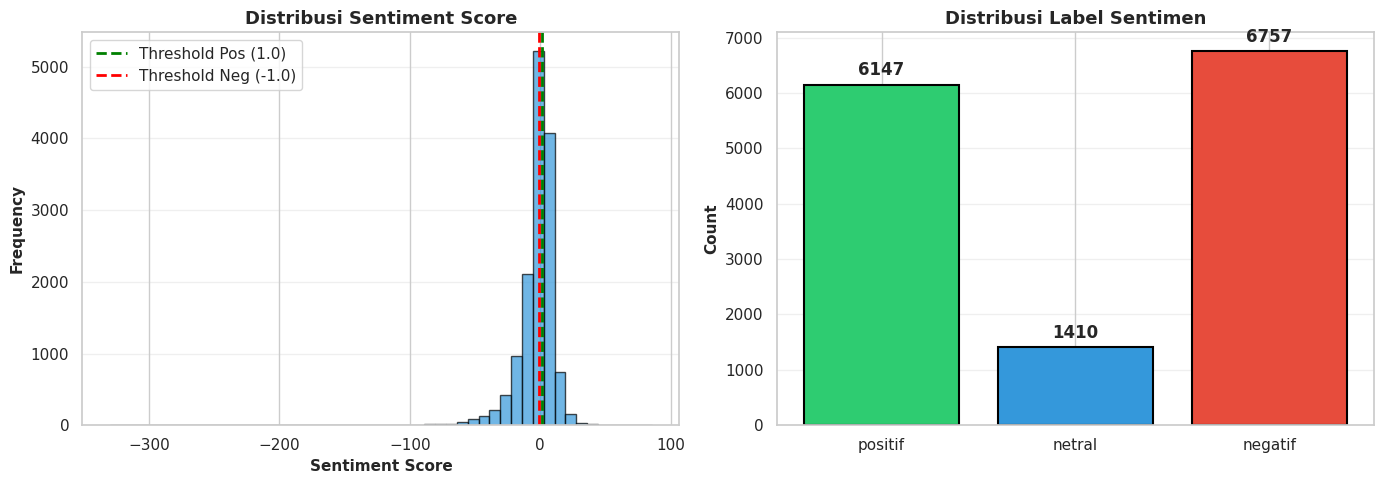


✓ Sentiment analysis visualization tersimpan: 01_sentiment_analysis_overview.png


In [ ]:
# Distribution
print(f"📊 DISTRIBUSI LABEL SENTIMEN:")
label_counts = df["label"].value_counts()
for label in ["positif", "netral", "negatif"]:
    count = label_counts.get(label, 0)
    pct = (count / len(df)) * 100
    print(f"  {label:10s} : {count:7,} ({pct:5.1f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df["sentiment_score"], bins=50, color="#3498db", edgecolor="black", alpha=0.7)
ax1.axvline(THRESHOLD_SENTIMENT, color="green", linestyle="--", linewidth=2,
            label=f"Threshold Pos ({THRESHOLD_SENTIMENT})")
ax1.axvline(-THRESHOLD_SENTIMENT, color="red", linestyle="--", linewidth=2,
            label=f"Threshold Neg ({-THRESHOLD_SENTIMENT})")
ax1.set_xlabel("Sentiment Score", fontweight='bold')
ax1.set_ylabel("Frequency", fontweight='bold')
ax1.set_title("Distribusi Sentiment Score", fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Bar chart
ax2 = axes[1]
colors = {"positif": "#2ecc71", "netral": "#3498db", "negatif": "#e74c3c"}
order = ["positif", "netral", "negatif"]
counts = [label_counts.get(label, 0) for label in order]
bars = ax2.bar(order, counts, color=[colors[l] for l in order], edgecolor="black", linewidth=1.5)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100, str(count),
            ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel("Count", fontweight='bold')
ax2.set_title("Distribusi Label Sentimen", fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("01_sentiment_analysis_overview.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Sentiment analysis visualization tersimpan: 01_sentiment_analysis_overview.png")

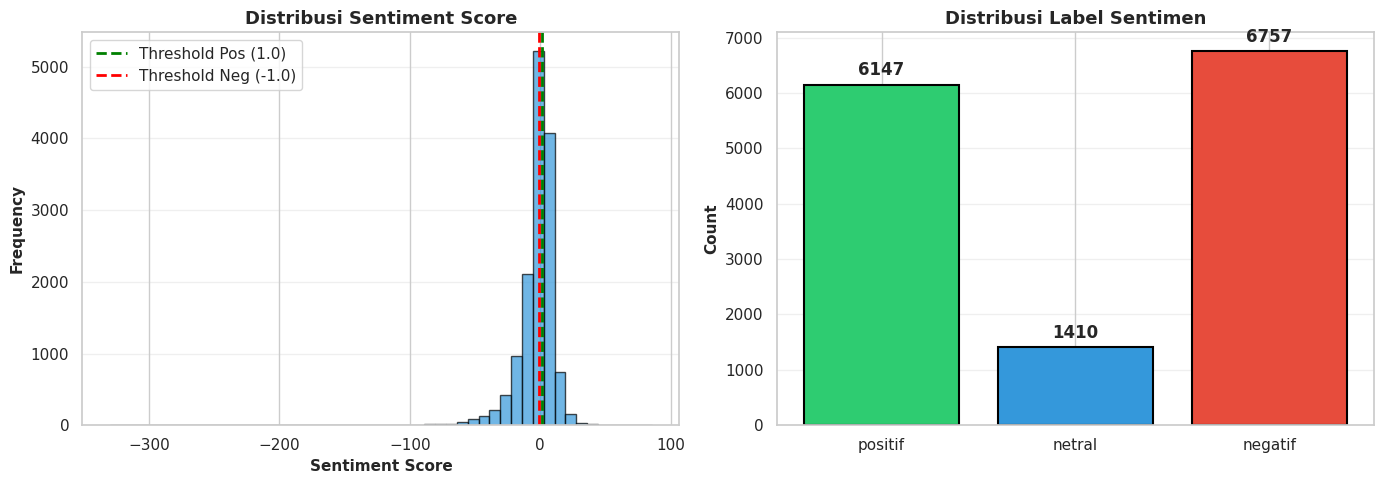


✓ Sentiment analysis visualization tersimpan: 01_sentiment_analysis_overview.png


In [ ]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df["sentiment_score"], bins=50, color="#3498db", edgecolor="black", alpha=0.7)
ax1.axvline(THRESHOLD_SENTIMENT, color="green", linestyle="--", linewidth=2,
            label=f"Threshold Pos ({THRESHOLD_SENTIMENT})")
ax1.axvline(-THRESHOLD_SENTIMENT, color="red", linestyle="--", linewidth=2,
            label=f"Threshold Neg ({-THRESHOLD_SENTIMENT})")
ax1.set_xlabel("Sentiment Score", fontweight='bold')
ax1.set_ylabel("Frequency", fontweight='bold')
ax1.set_title("Distribusi Sentiment Score", fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Bar chart
ax2 = axes[1]
colors = {"positif": "#2ecc71", "netral": "#3498db", "negatif": "#e74c3c"}
order = ["positif", "netral", "negatif"]
counts = [label_counts.get(label, 0) for label in order]
bars = ax2.bar(order, counts, color=[colors[l] for l in order], edgecolor="black", linewidth=1.5)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100, str(count),
            ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel("Count", fontweight='bold')
ax2.set_title("Distribusi Label Sentimen", fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("01_sentiment_analysis_overview.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Sentiment analysis visualization tersimpan: 01_sentiment_analysis_overview.png")


🔄 Mengumpulkan kata per sentimen...

✓ Kata terkumpul:
  Positif: 22,372
  Negatif: 51,371
  Netral:  9,925

🎨 Membuat WordCloud...



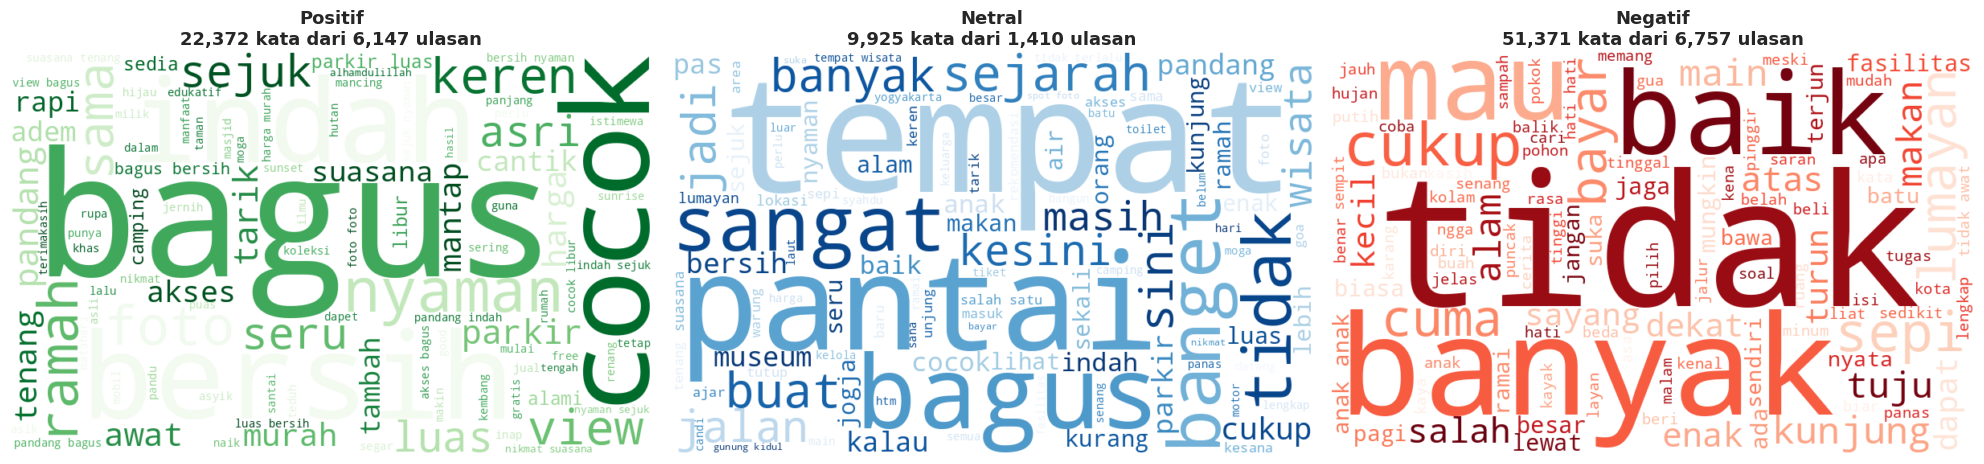

✓ WordCloud tersimpan: 02_wordcloud_sentiment_classes.png


In [ ]:
def kumpulkan_kata_sentimen(sub_df, arah):
    """Kumpulkan kata berdasarkan sentimen"""
    kata_list = []

    for matched_terms in sub_df["matched_terms"]:
        if not isinstance(matched_terms, list):
            continue

        for match_item in matched_terms:
            kata = str(match_item.get('word', '')).strip()
            bobot_efektif = float(match_item.get('final_weight', 0))

            if arah == "positif" and bobot_efektif > 0:
                kata_list.append(kata)
            elif arah == "negatif" and bobot_efektif < 0:
                kata_list.append(kata)

    return " ".join(kata_list) if kata_list else ""

print("\n🔄 Mengumpulkan kata per sentimen...\n")

df_pos = df[df["label"] == "positif"]
teks_pos = kumpulkan_kata_sentimen(df_pos, "positif")
count_pos = len(teks_pos.split())

df_neg = df[df["label"] == "negatif"]
teks_neg = kumpulkan_kata_sentimen(df_neg, "negatif")
count_neg = len(teks_neg.split())

df_netral = df[df["label"] == "netral"]
teks_netral = " ".join(df_netral["clean_text"].astype(str))
count_netral = len(teks_netral.split())

print(f"✓ Kata terkumpul:")
print(f"  Positif: {count_pos:,}")
print(f"  Negatif: {count_neg:,}")
print(f"  Netral:  {count_netral:,}\n")

# Generate WordCloud
print("🎨 Membuat WordCloud...\n")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

texts = [teks_pos, teks_netral, teks_neg]
titles = ["Positif", "Netral", "Negatif"]
cmaps = ["Greens", "Blues", "Reds"]
counts = [count_pos, count_netral, count_neg]

for ax, teks, title, cmap, count in zip(axes, texts, titles, cmaps, counts):
    if teks.strip():
        wc = WordCloud(width=800, height=500, background_color="white",
                      colormap=cmap, max_words=100, prefer_horizontal=0.7,
                      min_font_size=10).generate(teks)
        ax.imshow(wc, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "Tidak ada kata", ha='center', va='center',
               fontsize=14, color='gray')

    n_docs = [len(df_pos), len(df_netral), len(df_neg)][titles.index(title)]
    ax.set_title(f"{title}\n{count:,} kata dari {n_docs:,} ulasan", fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.savefig("02_wordcloud_sentiment_classes.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ WordCloud tersimpan: 02_wordcloud_sentiment_classes.png")


📊 TOP 20 KATA POSITIF:

   1. bagus           : 1,853 kali
   2. bersih          :   886 kali
   3. cocok           :   755 kali
   4. indah           :   731 kali
   5. nyaman          :   716 kali
   6. foto            :   622 kali
   7. sejuk           :   610 kali
   8. pandang         :   562 kali
   9. ramah           :   531 kali
  10. luas            :   470 kali
  11. parkir          :   458 kali
  12. suasana         :   457 kali
  13. view            :   425 kali
  14. asri            :   386 kali
  15. sama            :   342 kali
  16. tenang          :   320 kali
  17. keren           :   301 kali
  18. nikmat          :   293 kali
  19. murah           :   289 kali
  20. seru            :   283 kali

📊 TOP 20 KATA NEGATIF:

   1. tidak           : 3,259 kali
   2. banyak          : 1,673 kali
   3. anak            : 1,020 kali
   4. cukup           : 1,006 kali
   5. baik            :   891 kali
   6. makan           :   751 kali
   7. mau             :   719 kali
   8.

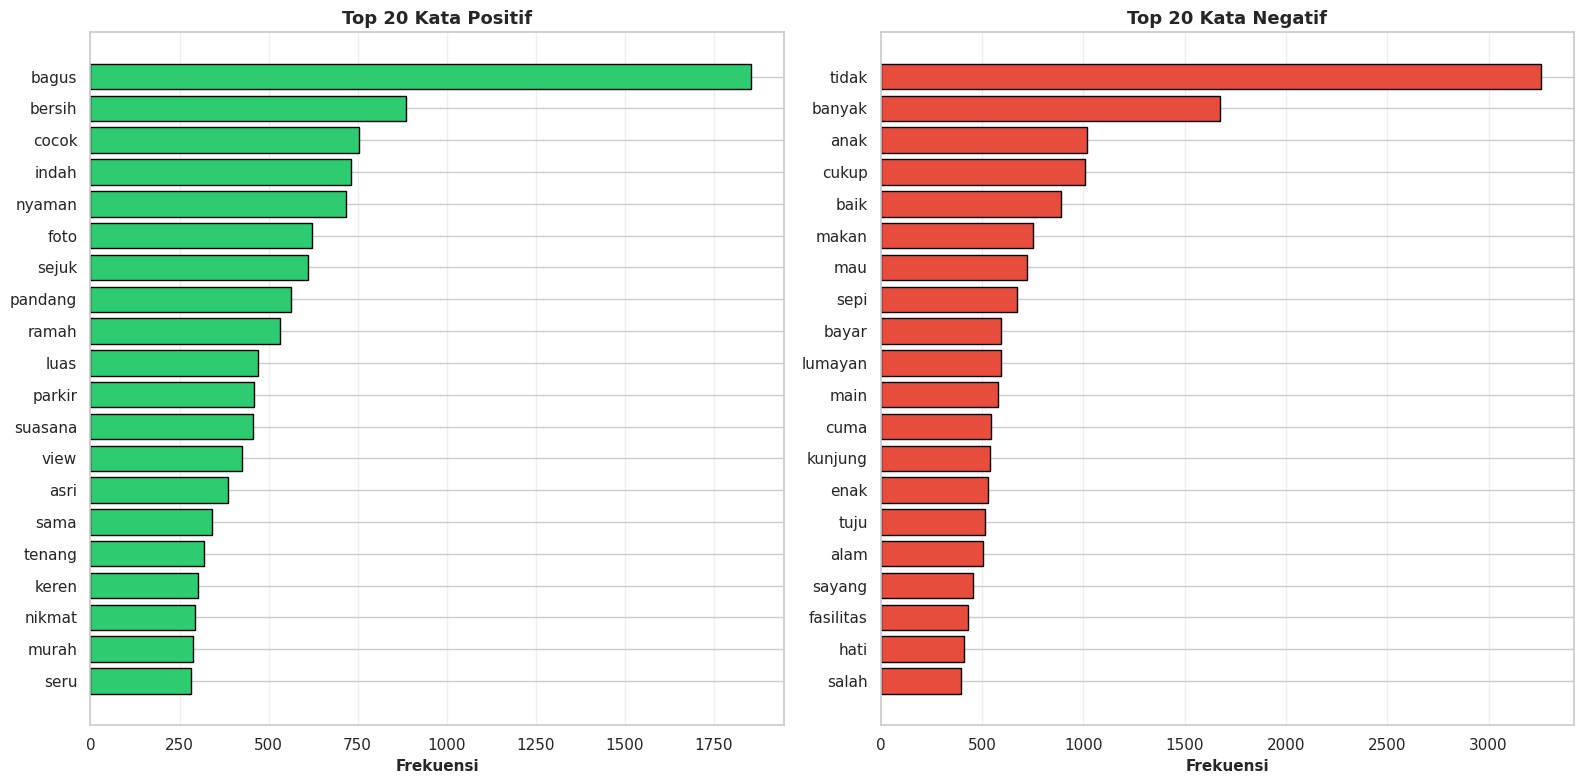


✓ Top words visualization tersimpan: 03_top_sentiment_words.png


In [ ]:
def get_top_words(sub_df, arah, top_n=20):
    """Dapatkan top N kata dengan frekuensi"""
    kata_counter = Counter()

    for matched_terms in sub_df["matched_terms"]:
        if not isinstance(matched_terms, list):
            continue

        for match_item in matched_terms:
            kata = str(match_item.get('word', '')).strip()
            bobot = float(match_item.get('final_weight', 0))

            if arah == "positif" and bobot > 0:
                kata_counter[kata] += 1
            elif arah == "negatif" and bobot < 0:
                kata_counter[kata] += 1

    return kata_counter.most_common(top_n)

top_pos = get_top_words(df[df["label"] == "positif"], "positif", 20)
top_neg = get_top_words(df[df["label"] == "negatif"], "negatif", 20)

print(f"\n📊 TOP 20 KATA POSITIF:\n")
for i, (kata, freq) in enumerate(top_pos, 1):
    print(f"  {i:2d}. {kata:15s} : {freq:5,} kali")

print(f"\n📊 TOP 20 KATA NEGATIF:\n")
for i, (kata, freq) in enumerate(top_neg, 1):
    print(f"  {i:2d}. {kata:15s} : {freq:5,} kali")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Positif
kata_pos = [k for k, _ in top_pos]
freq_pos = [f for _, f in top_pos]
axes[0].barh(range(len(kata_pos)), freq_pos, color="#2ecc71", edgecolor="black")
axes[0].set_yticks(range(len(kata_pos)))
axes[0].set_yticklabels(kata_pos)
axes[0].set_xlabel("Frekuensi", fontweight='bold')
axes[0].set_title("Top 20 Kata Positif", fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Negatif
kata_neg = [k for k, _ in top_neg]
freq_neg = [f for _, f in top_neg]
axes[1].barh(range(len(kata_neg)), freq_neg, color="#e74c3c", edgecolor="black")
axes[1].set_yticks(range(len(kata_neg)))
axes[1].set_yticklabels(kata_neg)
axes[1].set_xlabel("Frekuensi", fontweight='bold')
axes[1].set_title("Top 20 Kata Negatif", fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("03_top_sentiment_words.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Top words visualization tersimpan: 03_top_sentiment_words.png")


🔄 Melakukan TF-IDF vectorization...

✓ TF-IDF selesai
  Dimensi matriks    : (14314, 9781)
  Jumlah dokumen     : 14,314
  Jumlah fitur       : 9,781
  Sparsity           : 99.79%

📊 TOP 20 TF-IDF FEATURES:

   1. tempat               : 0.031706
   2. bagus                : 0.028152
   3. pantai               : 0.024734
   4. tidak                : 0.019838
   5. sangat               : 0.016246
   6. buat                 : 0.015815
   7. banget               : 0.015483
   8. banyak               : 0.014843
   9. jalan                : 0.014642
  10. bersih               : 0.014144
  11. indah                : 0.013369
  12. nyaman               : 0.013308
  13. wisata               : 0.011966
  14. sejuk                : 0.011551
  15. baik                 : 0.011375
  16. cocok                : 0.011294
  17. masih                : 0.011125
  18. anak                 : 0.011051
  19. pandang              : 0.010932
  20. jadi                 : 0.010923


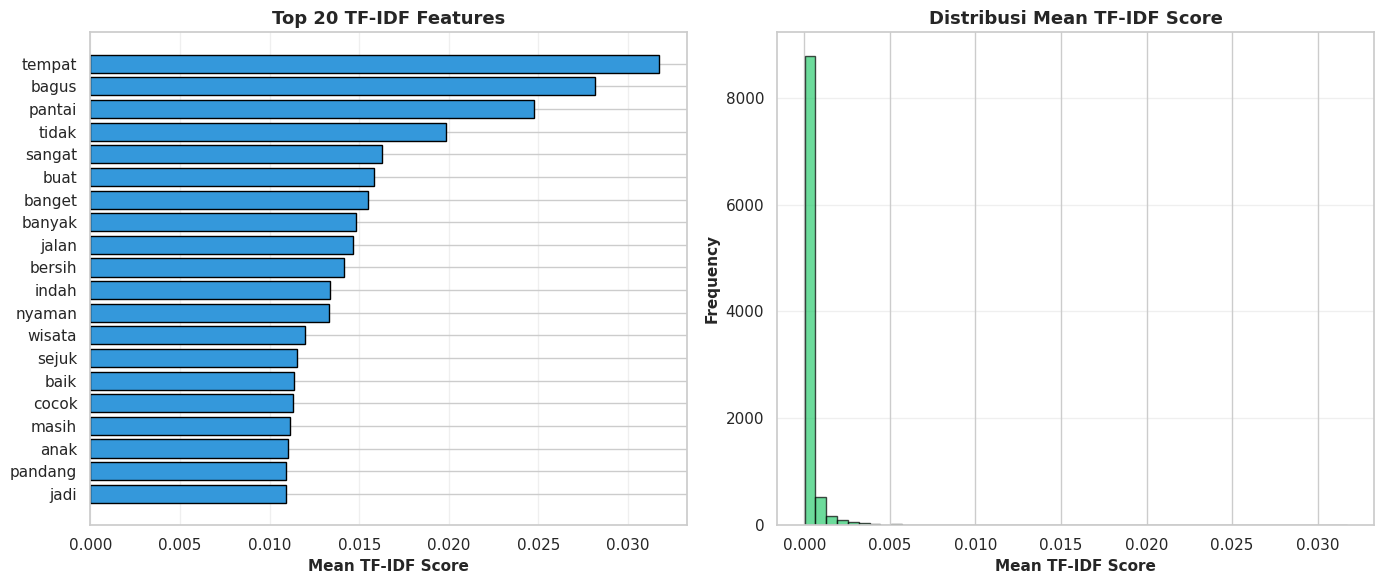


✓ TF-IDF features visualization tersimpan: 04_tfidf_features.png


In [ ]:
#Feature
X_text = df["clean_text"]
y = df["label"]

print(f"\n🔄 Melakukan TF-IDF vectorization...\n")

tfidf = TfidfVectorizer(
    max_features=None,
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
    lowercase=True,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X_text)

print(f"✓ TF-IDF selesai")
print(f"  Dimensi matriks    : {X_tfidf.shape}")
print(f"  Jumlah dokumen     : {X_tfidf.shape[0]:,}")
print(f"  Jumlah fitur       : {X_tfidf.shape[1]:,}")
print(f"  Sparsity           : {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%\n")

# Top TF-IDF features
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_tfidf_idx = mean_tfidf.argsort()[-20:][::-1]

print(f"📊 TOP 20 TF-IDF FEATURES:\n")
for i, idx in enumerate(top_tfidf_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:20s} : {mean_tfidf[idx]:.6f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top features
top_features = feature_names[top_tfidf_idx]
top_values = mean_tfidf[top_tfidf_idx]

axes[0].barh(range(len(top_features)), top_values, color="#3498db", edgecolor="black")
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features)
axes[0].set_xlabel("Mean TF-IDF Score", fontweight='bold')
axes[0].set_title("Top 20 TF-IDF Features", fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Distribution
axes[1].hist(mean_tfidf, bins=50, color="#2ecc71", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Mean TF-IDF Score", fontweight='bold')
axes[1].set_ylabel("Frequency", fontweight='bold')
axes[1].set_title("Distribusi Mean TF-IDF Score", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("04_tfidf_features.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ TF-IDF features visualization tersimpan: 04_tfidf_features.png")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"\n✓ Data split selesai\n")
print(f"📊 DATA LATIH:")
print(f"  Jumlah: {X_train.shape[0]:,} ({(X_train.shape[0]/len(y))*100:.1f}%)")
print(f"  Fitur: {X_train.shape[1]:,}")

print(f"\n📊 DATA UJI:")
print(f"  Jumlah: {X_test.shape[0]:,} ({(X_test.shape[0]/len(y))*100:.1f}%)")
print(f"  Fitur: {X_test.shape[1]:,}")

print(f"\n📊 DISTRIBUSI KELAS DATA LATIH:")
train_dist = pd.Series(y_train).value_counts()
for label in ["positif", "netral", "negatif"]:
    count = train_dist.get(label, 0)
    pct = (count / len(y_train)) * 100
    print(f"  {label:10s} : {count:6,} ({pct:5.1f}%)")


✓ Data split selesai

📊 DATA LATIH:
  Jumlah: 11,451 (80.0%)
  Fitur: 9,781

📊 DATA UJI:
  Jumlah: 2,863 (20.0%)
  Fitur: 9,781

📊 DISTRIBUSI KELAS DATA LATIH:
  positif    :  4,918 ( 42.9%)
  netral     :  1,128 (  9.9%)
  negatif    :  5,405 ( 47.2%)


In [ ]:
kernels_to_compare = [
    {
        "name": "linear",
        "model": SVC(kernel="linear", C=10, class_weight="balanced",
                     random_state=RANDOM_STATE, probability=True),
        "param": "C=10"
    },
    {
        "name": "rbf",
        "model": SVC(kernel="rbf", C=100, gamma="scale", class_weight="balanced",
                     random_state=RANDOM_STATE, probability=True),
        "param": "C=100, γ=scale"
    }
]

kernel_results = []

for kernel_config in kernels_to_compare:
    kernel_name = kernel_config["name"]
    model = kernel_config["model"]

    print(f"\n{'='*80}")
    print(f"Testing: {kernel_name.upper()} ({kernel_config['param']})")
    print('='*80)

    # Cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_results = cross_validate(
        model, X_train, y_train,
        cv=skf,
        scoring={"f1_macro": "f1_macro", "accuracy": "accuracy",
                "precision_macro": "precision_macro", "recall_macro": "recall_macro"},
        n_jobs=-1
    )

    cv_f1 = cv_results["test_f1_macro"]
    cv_acc = cv_results["test_accuracy"]

    print(f"\nCV F1-macro: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"  Per fold: {np.round(cv_f1, 4)}")

    # Fit & test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    test_prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    test_rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\nTest Set Metrics:")
    print(f"  Accuracy  : {test_acc:.4f}")
    print(f"  F1-macro  : {test_f1:.4f}")
    print(f"  Precision : {test_prec:.4f}")
    print(f"  Recall    : {test_rec:.4f}")

    kernel_results.append({
        "kernel": kernel_name,
        "params": kernel_config["param"],
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1,
        "test_precision_macro": test_prec,
        "test_recall_macro": test_rec,
    })

# Compare
comparison_df = pd.DataFrame(kernel_results)

print(f"\n{'='*80}")
print("PERBANDINGAN LINEAR vs RBF")
print('='*80)
print(comparison_df[["kernel", "cv_f1_mean", "test_f1_macro"]].to_string(index=False))

best_kernel_idx = comparison_df["test_f1_macro"].idxmax()
best_kernel = comparison_df.loc[best_kernel_idx, "kernel"]

print(f"\n✓ KERNEL TERPILIH: {best_kernel.upper()}")
print(f"  F1-macro: {comparison_df.loc[best_kernel_idx, 'test_f1_macro']:.4f}")

comparison_df.to_csv("05_kernel_comparison.csv", index=False)


Testing: LINEAR (C=10)

CV F1-macro: 0.7496 ± 0.0102
  Per fold: [0.7592 0.7497 0.744  0.7614 0.7335]

Test Set Metrics:
  Accuracy  : 0.8323
  F1-macro  : 0.7599
  Precision : 0.7524
  Recall    : 0.7696

Testing: RBF (C=100, γ=scale)

CV F1-macro: 0.7502 ± 0.0174
  Per fold: [0.7398 0.7623 0.7575 0.7698 0.7216]

Test Set Metrics:
  Accuracy  : 0.8523
  F1-macro  : 0.7514
  Precision : 0.8206
  Recall    : 0.7255

PERBANDINGAN LINEAR vs RBF
kernel  cv_f1_mean  test_f1_macro
linear    0.749578       0.759862
   rbf    0.750199       0.751370

✓ KERNEL TERPILIH: LINEAR
  F1-macro: 0.7599


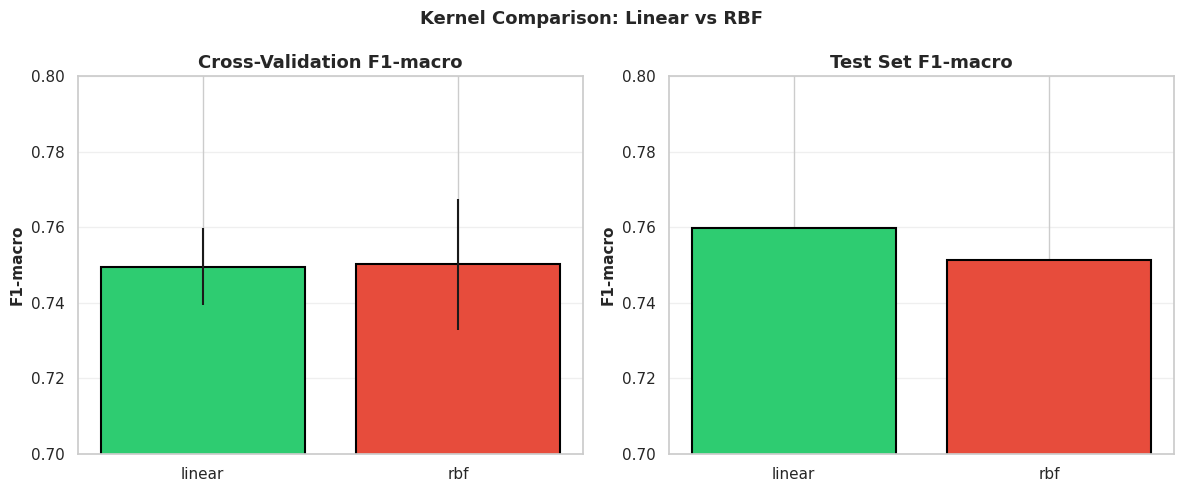


✓ Kernel comparison saved: 05_kernel_comparison.png


In [ ]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#2ecc71" if comparison_df.loc[i, "test_f1_macro"] == comparison_df["test_f1_macro"].max()
          else "#e74c3c" for i in range(len(comparison_df))]

axes[0].bar(comparison_df["kernel"], comparison_df["cv_f1_mean"],
           color=colors, edgecolor="black", linewidth=1.5, yerr=comparison_df["cv_f1_std"])
axes[0].set_ylabel("F1-macro", fontweight='bold')
axes[0].set_title("Cross-Validation F1-macro", fontweight='bold')
axes[0].set_ylim([0.7, 0.8])
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(comparison_df["kernel"], comparison_df["test_f1_macro"],
           color=colors, edgecolor="black", linewidth=1.5)
axes[1].set_ylabel("F1-macro", fontweight='bold')
axes[1].set_title("Test Set F1-macro", fontweight='bold')
axes[1].set_ylim([0.7, 0.8])
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Kernel Comparison: Linear vs RBF", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("05_kernel_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Kernel comparison saved: 05_kernel_comparison.png")

In [ ]:
if best_kernel == "linear":
    param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
    print(f"\n🔄 Grid Search untuk SVM Linear...\n")
else:
    param_grid = {"C": [1, 5, 10, 20, 50], "gamma": ["scale", "auto", 0.001, 0.01, 0.1]}
    print(f"\n🔄 Grid Search untuk SVM RBF...\n")

n_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"  Parameter combinations: {n_combinations}")
print(f"  Cross-validation: 5-fold\n")

t_start = time.time()

grid_model = GridSearchCV(
    SVC(kernel=best_kernel, class_weight="balanced", random_state=RANDOM_STATE, probability=True),
    param_grid, cv=5, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_model.fit(X_train, y_train)

t_end = time.time()
grid_time = t_end - t_start

print(f"\n✓ Grid Search selesai ({grid_time:.2f} detik)")
print(f"\n  Best parameters: {grid_model.best_params_}")
print(f"  Best CV F1-macro: {grid_model.best_score_:.4f}")

best_model = grid_model.best_estimator_


🔄 Grid Search untuk SVM Linear...

  Parameter combinations: 5
  Cross-validation: 5-fold

Fitting 5 folds for each of 5 candidates, totalling 25 fits

✓ Grid Search selesai (1799.95 detik)

  Best parameters: {'C': 10}
  Best CV F1-macro: 0.7542


In [ ]:
# Grid search results
cv_results_df = pd.DataFrame(grid_model.cv_results_)
cv_results_df = cv_results_df[["param_C", "mean_test_score", "std_test_score", "rank_test_score"]]
if best_kernel == "rbf":
    cv_results_df["param_gamma"] = grid_model.cv_results_.get("param_gamma", "-")
cv_results_df = cv_results_df.sort_values("rank_test_score").head(10)

print(f"\n📊 TOP 10 GRID SEARCH RESULTS:\n")
print(cv_results_df.to_string(index=False))

cv_results_df.to_csv(f"06_gridsearch_{best_kernel}_results.csv", index=False)


📊 TOP 10 GRID SEARCH RESULTS:

 param_C  mean_test_score  std_test_score  rank_test_score
   10.00         0.754248        0.007477                1
  100.00         0.751520        0.006655                2
    1.00         0.734291        0.009059                3
    0.10         0.622553        0.007087                4
    0.01         0.518100        0.116544                5


In [ ]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro"
}

print(f"\n🔄 Running {N_FOLDS}-fold stratified cross-validation...\n")

cv_results = cross_validate(
    best_model, X_train, y_train, cv=skf, scoring=scoring,
    n_jobs=-1, return_train_score=True, verbose=1
)

# Extract scores
f1_scores = cv_results["test_f1_macro"]
accuracy_scores = cv_results["test_accuracy"]
precision_scores = cv_results["test_precision_macro"]
recall_scores = cv_results["test_recall_macro"]

print(f"\n{'='*80}")
print("CROSS-VALIDATION RESULTS")
print('='*80)

print(f"\n📊 F1-MACRO:")
print(f"   Per fold: {np.round(f1_scores, 4)}")
print(f"   Mean ± Std: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

print(f"\n📊 ACCURACY:")
print(f"   Per fold: {np.round(accuracy_scores, 4)}")
print(f"   Mean ± Std: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")

print(f"\n📊 PRECISION-MACRO:")
print(f"   Per fold: {np.round(precision_scores, 4)}")
print(f"   Mean ± Std: {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")

print(f"\n📊 RECALL-MACRO:")
print(f"   Per fold: {np.round(recall_scores, 4)}")
print(f"   Mean ± Std: {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")


🔄 Running 5-fold stratified cross-validation...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



CROSS-VALIDATION RESULTS

📊 F1-MACRO:
   Per fold: [0.7592 0.7497 0.744  0.7614 0.7335]
   Mean ± Std: 0.7496 ± 0.0102

📊 ACCURACY:
   Per fold: [0.8324 0.8135 0.8162 0.8288 0.81  ]
   Mean ± Std: 0.8202 ± 0.0088

📊 PRECISION-MACRO:
   Per fold: [0.7588 0.7386 0.7336 0.7545 0.7289]
   Mean ± Std: 0.7429 ± 0.0117

📊 RECALL-MACRO:
   Per fold: [0.7603 0.7678 0.7609 0.7714 0.7393]
   Mean ± Std: 0.7599 ± 0.0111


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.9min finished


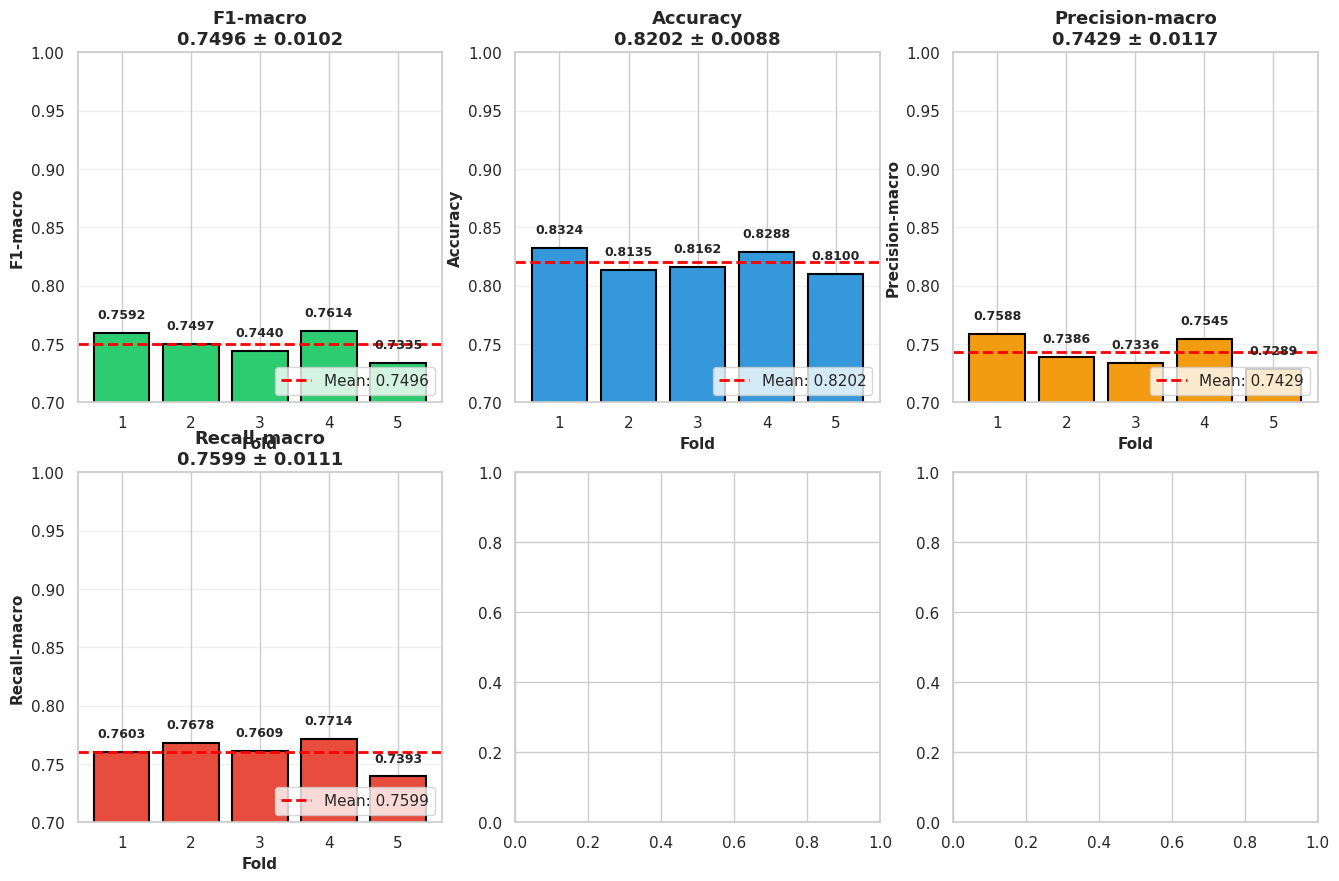

In [ ]:
# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics_data = [
    (f1_scores, "F1-macro", "#2ecc71"),
    (accuracy_scores, "Accuracy", "#3498db"),
    (precision_scores, "Precision-macro", "#f39c12"),
    (recall_scores, "Recall-macro", "#e74c3c"),
]

for idx, (ax, (scores, name, color)) in enumerate(zip(axes.flatten()[:4], metrics_data)):
    bars = ax.bar(range(1, N_FOLDS+1), scores, color=color, edgecolor="black", linewidth=1.5)

    ax.axhline(scores.mean(), color="red", linestyle="--", linewidth=2,
              label=f"Mean: {scores.mean():.4f}")

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2., score + 0.01, f'{score:.4f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel("Fold", fontweight='bold')
    ax.set_ylabel(name, fontweight='bold')
    ax.set_title(f"{name}\n{scores.mean():.4f} ± {scores.std():.4f}", fontweight='bold')
    ax.set_ylim([0.7, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='lower right')

In [ ]:
# Box plot
ax_box = axes.flatten()[4]
box_data = [f1_scores, accuracy_scores, precision_scores, recall_scores]
bp = ax_box.boxplot(box_data, labels=["F1", "Acc", "Prec", "Rec"], patch_artist=True)

colors_box = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_box.set_ylabel("Score", fontweight='bold')
ax_box.set_title("Distribution of Metrics", fontweight='bold')
ax_box.grid(True, alpha=0.3, axis='y')

axes.flatten()[5].remove()

plt.suptitle(f"SVM {best_kernel.upper()}: {N_FOLDS}-Fold CV", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"06_cv_analysis_{best_kernel}.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ CV analysis visualization saved")

<Figure size 1000x600 with 0 Axes>


✓ CV analysis visualization saved


In [ ]:
# Summary
cv_summary = pd.DataFrame({
    "Metric": ["F1-macro", "Accuracy", "Precision-macro", "Recall-macro"],
    "Mean": [f1_scores.mean(), accuracy_scores.mean(), precision_scores.mean(), recall_scores.mean()],
    "Std": [f1_scores.std(), accuracy_scores.std(), precision_scores.std(), recall_scores.std()],
    "Min": [f1_scores.min(), accuracy_scores.min(), precision_scores.min(), recall_scores.min()],
    "Max": [f1_scores.max(), accuracy_scores.max(), precision_scores.max(), recall_scores.max()]
})

cv_summary.to_csv(f"06_cv_summary_{best_kernel}.csv", index=False)

In [ ]:
t_start = time.time()
y_pred_svm = best_model.predict(X_test)
y_pred_proba_svm = best_model.predict_proba(X_test)
t_end = time.time()
pred_time_svm = t_end - t_start

# Metrics
test_acc_svm = accuracy_score(y_test, y_pred_svm)
test_prec_svm = precision_score(y_test, y_pred_svm, average="macro", zero_division=0)
test_rec_svm = recall_score(y_test, y_pred_svm, average="macro", zero_division=0)
test_f1_svm = f1_score(y_test, y_pred_svm, average="macro", zero_division=0)

print(f"✓ Prediction time: {pred_time_svm*1000:.2f} ms\n")

print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_svm, digits=4))

✓ Prediction time: 5392.23 ms

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     negatif     0.8690    0.8639    0.8665      1352
      netral     0.5076    0.5922    0.5466       282
     positif     0.8807    0.8527    0.8665      1229

    accuracy                         0.8323      2863
   macro avg     0.7524    0.7696    0.7599      2863
weighted avg     0.8384    0.8323    0.8350      2863



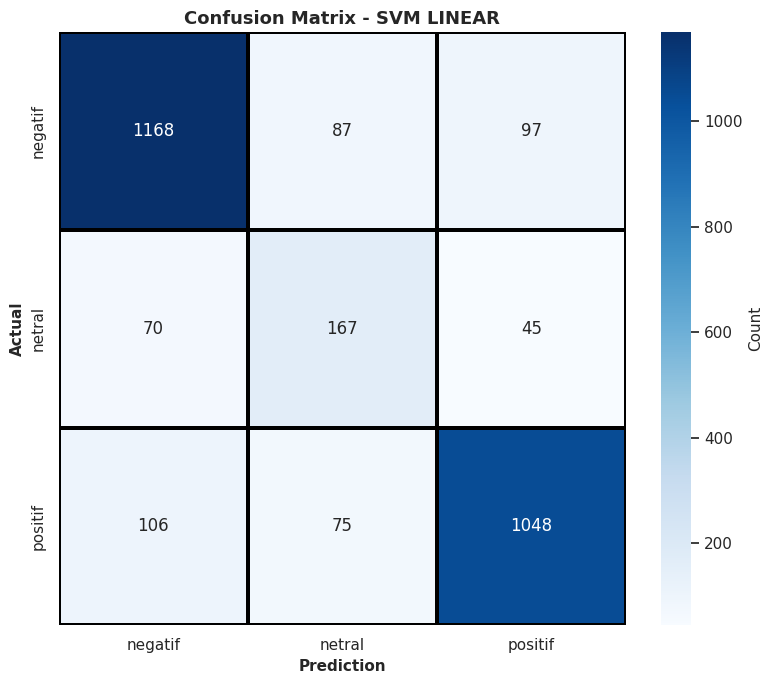

✓ Confusion matrix saved: 07_confusion_matrix_linear.png


In [ ]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
           xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()),
           cbar_kws={"label": "Count"}, ax=ax, linewidths=1.5, linecolor="black")

ax.set_title(f"Confusion Matrix - SVM {best_kernel.upper()}", fontweight='bold')
ax.set_xlabel("Prediction", fontweight='bold')
ax.set_ylabel("Actual", fontweight='bold')

plt.tight_layout()
plt.savefig(f"07_confusion_matrix_{best_kernel}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved: 07_confusion_matrix_{best_kernel}.png")

In [ ]:
# Store results
hasil_svm = {
    "Model": f"SVM {best_kernel.upper()}",
    "Accuracy": test_acc_svm,
    "Precision-macro": test_prec_svm,
    "Recall-macro": test_rec_svm,
    "F1-macro": test_f1_svm,
    "CV F1-macro Mean": f1_scores.mean(),
    "CV F1-macro Std": f1_scores.std(),
    "Best Params": str(grid_model.best_params_),
    "Training Time (s)": grid_time,
    "Prediction Time (s)": pred_time_svm
}

hasil_svm_df = pd.DataFrame([hasil_svm])
hasil_svm_df.to_csv(f"07_test_evaluation_{best_kernel}.csv", index=False)

print(f"\n✓ Test evaluation saved: 07_test_evaluation_{best_kernel}.csv")


✓ Test evaluation saved: 07_test_evaluation_linear.csv


In [ ]:
param_grid_mnb = {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]}

print(f"  Parameter combinations: {len(param_grid_mnb['alpha'])}")

t_start = time.time()

grid_model_mnb = GridSearchCV(
    MultinomialNB(), param_grid_mnb, cv=5, scoring="f1_macro",
    n_jobs=-1, verbose=1
)

grid_model_mnb.fit(X_train, y_train)

t_end = time.time()
grid_time_mnb = t_end - t_start

print(f"\n✓ Grid Search selesai ({grid_time_mnb:.2f} detik)")
print(f"\n  Best parameters: {grid_model_mnb.best_params_}")
print(f"  Best CV F1-macro: {grid_model_mnb.best_score_:.4f}")

best_model_mnb = grid_model_mnb.best_estimator_

  Parameter combinations: 5
Fitting 5 folds for each of 5 candidates, totalling 25 fits

✓ Grid Search selesai (1.10 detik)

  Best parameters: {'alpha': 0.01}
  Best CV F1-macro: 0.5891


In [ ]:
# Cross-validation
print(f"\n🔄 Running {N_FOLDS}-fold cross-validation (MNB)...\n")

cv_results_mnb = cross_validate(
    best_model_mnb, X_train, y_train, cv=skf, scoring=scoring,
    n_jobs=-1, return_train_score=True, verbose=1
)

f1_mnb = cv_results_mnb["test_f1_macro"]
acc_mnb = cv_results_mnb["test_accuracy"]

print(f"\n📊 F1-MACRO:")
print(f"   Mean ± Std: {f1_mnb.mean():.4f} ± {f1_mnb.std():.4f}")

print(f"\n📊 ACCURACY:")
print(f"   Mean ± Std: {acc_mnb.mean():.4f} ± {acc_mnb.std():.4f}")

# Test evaluation
print(f"\n🔄 Predicting on test set (MNB)...\n")

t_start = time.time()
y_pred_mnb = best_model_mnb.predict(X_test)
y_pred_proba_mnb = best_model_mnb.predict_proba(X_test)
t_end = time.time()
pred_time_mnb = t_end - t_start

test_acc_mnb = accuracy_score(y_test, y_pred_mnb)
test_prec_mnb = precision_score(y_test, y_pred_mnb, average="macro", zero_division=0)
test_rec_mnb = recall_score(y_test, y_pred_mnb, average="macro", zero_division=0)
test_f1_mnb = f1_score(y_test, y_pred_mnb, average="macro", zero_division=0)

print(f"✓ Prediction time: {pred_time_mnb*1000:.2f} ms\n")

print("="*80)
print("CLASSIFICATION REPORT (MNB)")
print("="*80)
print(classification_report(y_test, y_pred_mnb, digits=4))


🔄 Running 5-fold cross-validation (MNB)...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



📊 F1-MACRO:
   Mean ± Std: 0.5823 ± 0.0084

📊 ACCURACY:
   Mean ± Std: 0.7312 ± 0.0033

🔄 Predicting on test set (MNB)...

✓ Prediction time: 4.42 ms

CLASSIFICATION REPORT (MNB)
              precision    recall  f1-score   support

     negatif     0.7223    0.8868    0.7961      1352
      netral     0.5231    0.1206    0.1960       282
     positif     0.7917    0.7331    0.7613      1229

    accuracy                         0.7454      2863
   macro avg     0.6790    0.5802    0.5845      2863
weighted avg     0.7325    0.7454    0.7221      2863



[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.9s finished


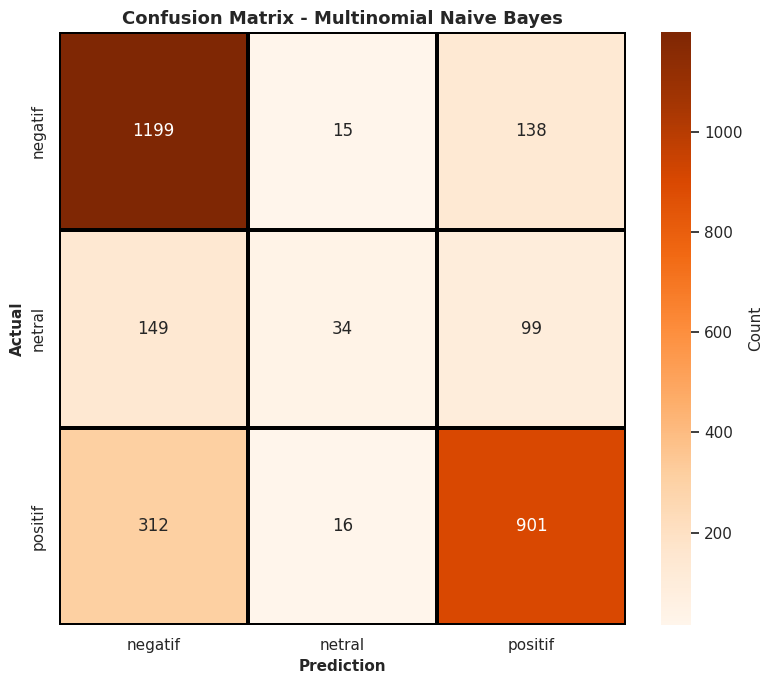

✓ Confusion matrix saved: 08_confusion_matrix_mnb.png


In [ ]:
# Confusion matrix
cm_mnb = confusion_matrix(y_test, y_pred_mnb, labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_mnb, annot=True, fmt="d", cmap="Oranges",
           xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()),
           cbar_kws={"label": "Count"}, ax=ax, linewidths=1.5, linecolor="black")

ax.set_title("Confusion Matrix - Multinomial Naive Bayes", fontweight='bold')
ax.set_xlabel("Prediction", fontweight='bold')
ax.set_ylabel("Actual", fontweight='bold')

plt.tight_layout()
plt.savefig("08_confusion_matrix_mnb.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved: 08_confusion_matrix_mnb.png")

In [ ]:
# Store results
hasil_mnb = {
    "Model": "Multinomial Naive Bayes",
    "Accuracy": test_acc_mnb,
    "Precision-macro": test_prec_mnb,
    "Recall-macro": test_rec_mnb,
    "F1-macro": test_f1_mnb,
    "CV F1-macro Mean": f1_mnb.mean(),
    "CV F1-macro Std": f1_mnb.std(),
    "Best Params": str(grid_model_mnb.best_params_),
    "Training Time (s)": grid_time_mnb,
    "Prediction Time (s)": pred_time_mnb
}

hasil_mnb_df = pd.DataFrame([hasil_mnb])
hasil_mnb_df.to_csv("08_test_evaluation_mnb.csv", index=False)

In [ ]:
# Combine results
comparison_models = pd.concat([hasil_svm_df, hasil_mnb_df], ignore_index=True)

print(f"\n{'='*80}")
print("COMPARISON SUMMARY")
print('='*80)
print(comparison_models.to_string(index=False))

comparison_models.to_csv("09_model_comparison.csv", index=False)

# Determine best model
best_model_idx = comparison_models["F1-macro"].idxmax()
best_overall_model_name = comparison_models.loc[best_model_idx, "Model"]
best_overall_f1 = comparison_models.loc[best_model_idx, "F1-macro"]


COMPARISON SUMMARY
                  Model  Accuracy  Precision-macro  Recall-macro  F1-macro  CV F1-macro Mean  CV F1-macro Std     Best Params  Training Time (s)  Prediction Time (s)
             SVM LINEAR  0.832344         0.752440      0.769610  0.759862          0.749578         0.010241       {'C': 10}        1799.953947             5.392233
Multinomial Naive Bayes  0.745372         0.679035      0.580173  0.584472          0.582330         0.008388 {'alpha': 0.01}           1.102275             0.004416



✓ BEST MODEL: SVM LINEAR
  F1-macro: 0.7599


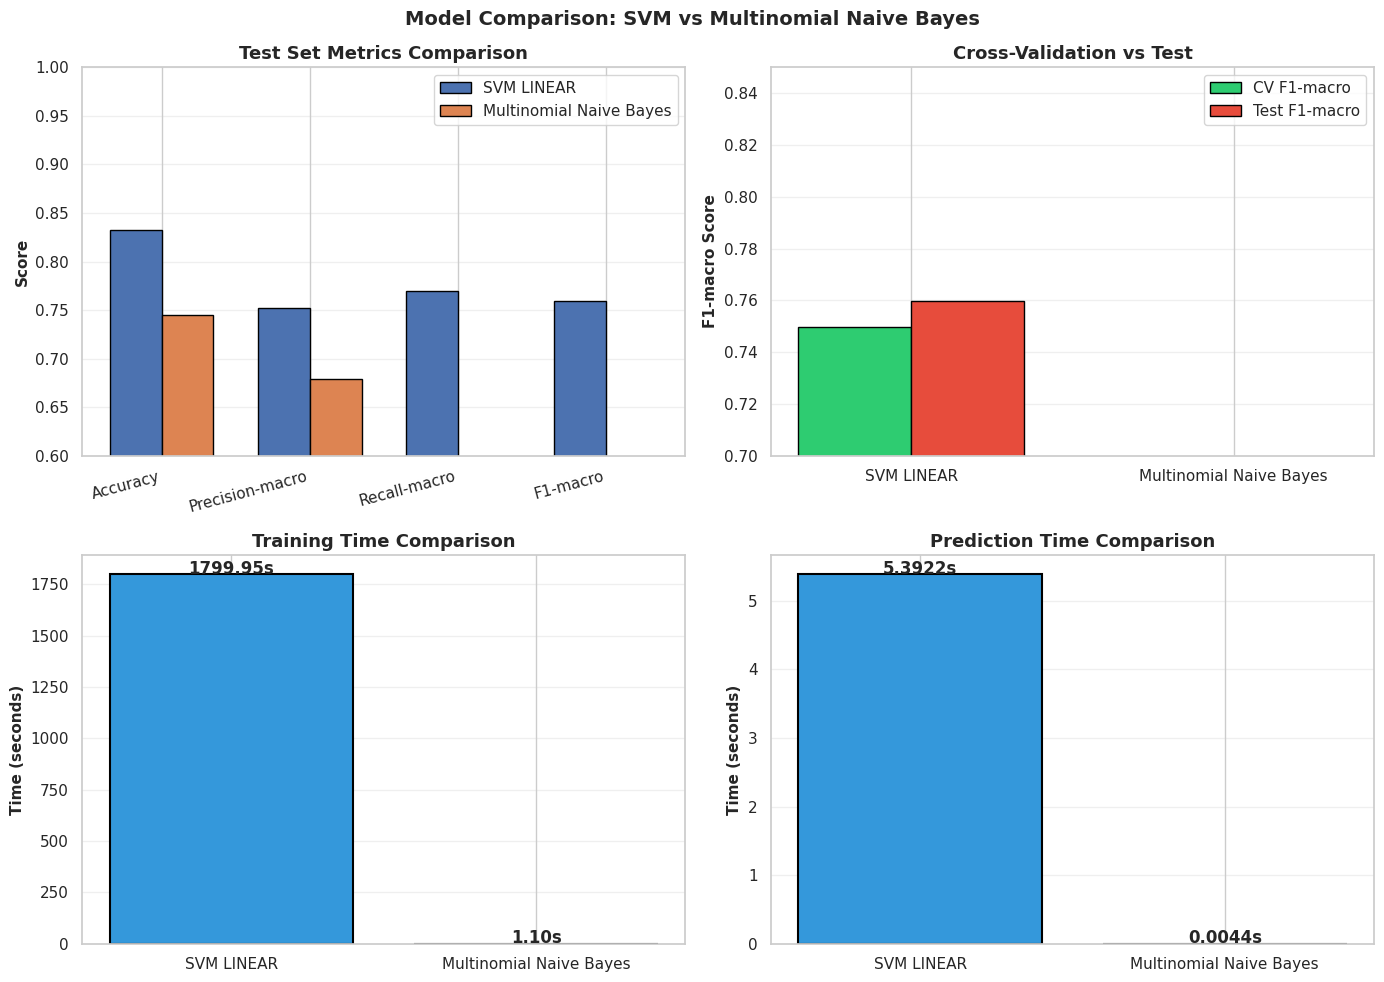


✓ Model comparison visualization saved: 09_model_comparison.png


In [ ]:
print(f"\n{'='*80}")
print(f"✓ BEST MODEL: {best_overall_model_name}")
print(f"  F1-macro: {best_overall_f1:.4f}")
print('='*80)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall metrics
ax1 = axes[0, 0]
metrics_names = ["Accuracy", "Precision-macro", "Recall-macro", "F1-macro"]
model_names = comparison_models["Model"].tolist()

x = np.arange(len(metrics_names))
width = 0.35

for i, model_name in enumerate(model_names):
    values = [comparison_models.loc[i, m] for m in metrics_names]
    ax1.bar(x + i*width, values, width, label=model_name, edgecolor="black")

ax1.set_ylabel("Score", fontweight='bold')
ax1.set_title("Test Set Metrics Comparison", fontweight='bold')
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(metrics_names, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0.6, 1.0])
ax1.grid(True, alpha=0.3, axis='y')

# CV vs Test F1
ax2 = axes[0, 1]
cv_f1_means = comparison_models["CV F1-macro Mean"].tolist()
test_f1s = comparison_models["F1-macro"].tolist()

x2 = np.arange(len(model_names))
ax2.bar(x2 - width/2, cv_f1_means, width, label="CV F1-macro", color="#2ecc71", edgecolor="black")
ax2.bar(x2 + width/2, test_f1s, width, label="Test F1-macro", color="#e74c3c", edgecolor="black")

ax2.set_ylabel("F1-macro Score", fontweight='bold')
ax2.set_title("Cross-Validation vs Test", fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(model_names)
ax2.legend()
ax2.set_ylim([0.7, 0.85])
ax2.grid(True, alpha=0.3, axis='y')

# Training time
ax3 = axes[1, 0]
train_times = comparison_models["Training Time (s)"].tolist()
ax3.bar(model_names, train_times, color=["#3498db", "#f39c12"], edgecolor="black", linewidth=1.5)
ax3.set_ylabel("Time (seconds)", fontweight='bold')
ax3.set_title("Training Time Comparison", fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for i, t in enumerate(train_times):
    ax3.text(i, t + 0.5, f'{t:.2f}s', ha='center', fontweight='bold')

# Prediction time
ax4 = axes[1, 1]
pred_times = comparison_models["Prediction Time (s)"].tolist()
ax4.bar(model_names, pred_times, color=["#3498db", "#f39c12"], edgecolor="black", linewidth=1.5)
ax4.set_ylabel("Time (seconds)", fontweight='bold')
ax4.set_title("Prediction Time Comparison", fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

for i, t in enumerate(pred_times):
    ax4.text(i, t + 0.0001, f'{t:.4f}s', ha='center', fontweight='bold')

plt.suptitle("Model Comparison: SVM vs Multinomial Naive Bayes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("09_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison visualization saved: 09_model_comparison.png")

In [ ]:
# Select best model
if best_model_idx == 0:
    final_model = best_model
    final_model_name = f"SVM {best_kernel.upper()}"
else:
    final_model = best_model_mnb
    final_model_name = "Multinomial Naive Bayes"

print(f"\n✓ Final model: {final_model_name}")
print(f"  F1-macro: {best_overall_f1:.4f}\n")

# Predict full dataset
print(f"🔄 Predicting on full dataset...\n")

df["pred_label"] = final_model.predict(tfidf.transform(df["clean_text"]))
df["pred_proba"] = final_model.predict_proba(tfidf.transform(df["clean_text"])).max(axis=1)

print(f"✓ Predictions completed\n")

print(f"📊 DISTRIBUTION OF PREDICTIONS:")
pred_dist = df["pred_label"].value_counts()
for label in ["positif", "netral", "negatif"]:
    count = pred_dist.get(label, 0)
    pct = (count / len(df)) * 100
    print(f"  {label:10s} : {count:7,} ({pct:5.1f}%)")


✓ Final model: SVM LINEAR
  F1-macro: 0.7599

🔄 Predicting on full dataset...

✓ Predictions completed

📊 DISTRIBUTION OF PREDICTIONS:
  positif    :   6,099 ( 42.6%)
  netral     :   1,482 ( 10.4%)
  negatif    :   6,733 ( 47.0%)


In [ ]:
rekap_destinasi = df.groupby("title").agg(
    rata2_bintang=("stars", "mean"),
    std_bintang=("stars", "std"),
    jumlah_ulasan=("stars", "count"),
    rasio_positif=("pred_label", lambda x: (x == "positif").mean()),
    rasio_netral=("pred_label", lambda x: (x == "netral").mean()),
    rasio_negatif=("pred_label", lambda x: (x == "negatif").mean()),
    confidence_avg=("pred_proba", "mean"),
).reset_index()

# Recommendation score
rekap_destinasi["skor_rekomendasi"] = (
    (rekap_destinasi["rata2_bintang"] / 5) * 0.5 +
    rekap_destinasi["rasio_positif"] * 0.5
)

rekap_destinasi = rekap_destinasi.sort_values("skor_rekomendasi", ascending=False)
print(f"✓ Aggregation completed: {len(rekap_destinasi)} destinations\n")

print(f"📊 TOP 20 RECOMMENDED DESTINATIONS:\n")
for i, row in rekap_destinasi.head(20).iterrows():
    print(f"  {row['title'][:40]:40s} | Score: {row['skor_rekomendasi']:.3f} | "
          f"Rating: {row['rata2_bintang']:.2f}★ | Reviews: {int(row['jumlah_ulasan']):,}")

rekap_destinasi.to_csv("10_recommendation_results.csv", index=False)

✓ Aggregation completed: 323 destinations

📊 TOP 20 RECOMMENDED DESTINATIONS:

  Ekowisata Tritis Gunungkidul             | Score: 0.929 | Rating: 5.00★ | Reviews: 7
  Taman Jamu Naturindo                     | Score: 0.859 | Rating: 4.92★ | Reviews: 83
  Hutan Pinus Mangunan                     | Score: 0.854 | Rating: 4.93★ | Reviews: 54
  Makam Ki Ageng Giring Sukodono           | Score: 0.853 | Rating: 5.00★ | Reviews: 17
  Museum Sonobudoyo                        | Score: 0.842 | Rating: 4.93★ | Reviews: 43
  Puncak Becici                            | Score: 0.838 | Rating: 4.82★ | Reviews: 45
  Gunung Pinus Pengger                     | Score: 0.834 | Rating: 4.77★ | Reviews: 35
  Museum Anak Bajang                       | Score: 0.833 | Rating: 5.00★ | Reviews: 6
  Watu Amben                               | Score: 0.826 | Rating: 4.81★ | Reviews: 42
  Kampung Emas                             | Score: 0.823 | Rating: 4.79★ | Reviews: 48
  Rumah Sandi Negara                       

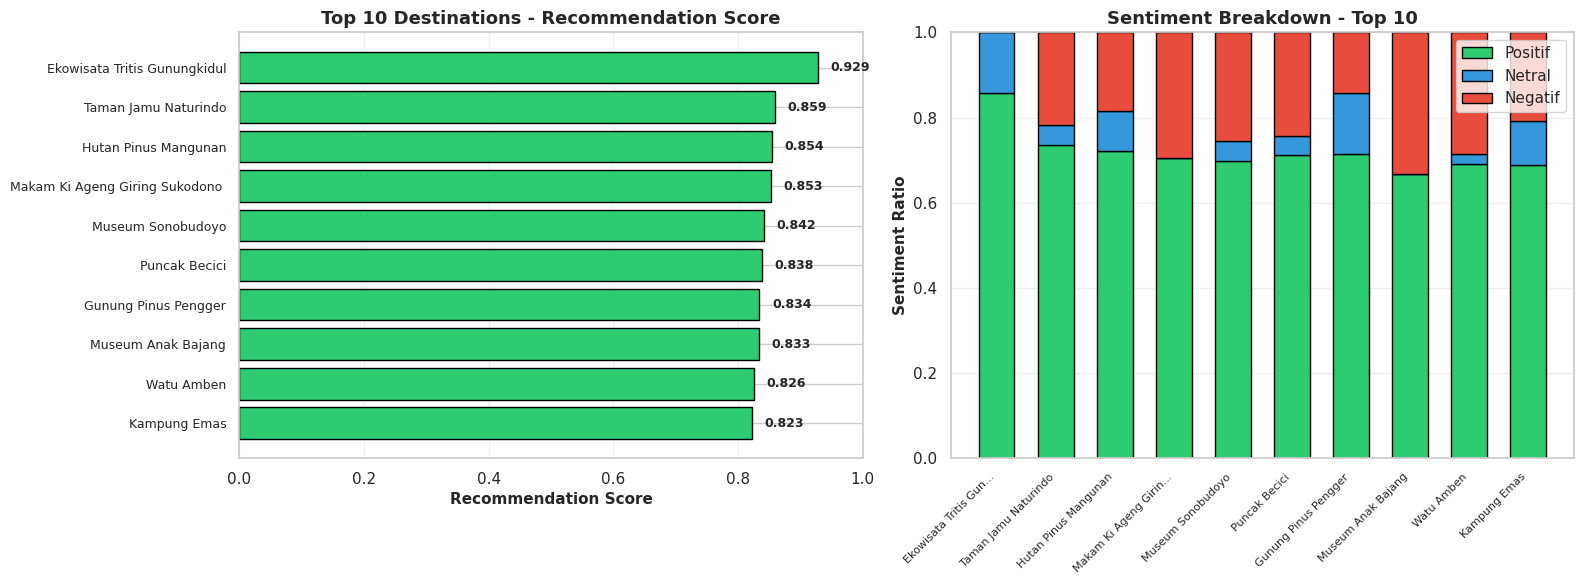


✓ Recommendation system visualizations saved


In [ ]:
# Visualisasi
top_10 = rekap_destinasi.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Skor rekomendasi
ax1 = axes[0]
bars = ax1.barh(range(len(top_10)), top_10["skor_rekomendasi"], color="#2ecc71", edgecolor="black")
ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels([d[:35] + "..." if len(d) > 35 else d for d in top_10["title"]], fontsize=9)
ax1.set_xlabel("Recommendation Score", fontweight='bold')
ax1.set_title("Top 10 Destinations - Recommendation Score", fontweight='bold')
ax1.set_xlim([0, 1])
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, score) in enumerate(zip(bars, top_10["skor_rekomendasi"])):
    ax1.text(score + 0.02, bar.get_y() + bar.get_height()/2., f'{score:.3f}',
            va='center', fontweight='bold', fontsize=9)

# Sentiment breakdown
ax2 = axes[1]
x_pos = np.arange(len(top_10))
width = 0.6

ax2.bar(x_pos, top_10["rasio_positif"], width, label="Positif", color="#2ecc71", edgecolor="black")
ax2.bar(x_pos, top_10["rasio_netral"], width, bottom=top_10["rasio_positif"],
       label="Netral", color="#3498db", edgecolor="black")
ax2.bar(x_pos, top_10["rasio_negatif"], width,
       bottom=top_10["rasio_positif"] + top_10["rasio_netral"],
       label="Negatif", color="#e74c3c", edgecolor="black")

ax2.set_xticks(x_pos)
ax2.set_xticklabels([d[:20] + "..." if len(d) > 20 else d for d in top_10["title"]],
                    rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("Sentiment Ratio", fontweight='bold')
ax2.set_title("Sentiment Breakdown - Top 10", fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("10_recommendation_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Recommendation system visualizations saved")

In [ ]:
print(f"\n📊 DATASET SUMMARY:")
print(f"  Total reviews: {len(df):,}")
print(f"  Unique destinations: {df['title'].nunique()}")
print(f"  TF-IDF features: {X_tfidf.shape[1]:,}")
print(f"  Sentiment lexicon: {len(lexicon)} words")

print(f"\n🎯 BEST MODEL: {final_model_name}")
print(f"  Test Accuracy: {comparison_models.loc[best_model_idx, 'Accuracy']:.4f}")
print(f"  Test F1-macro: {best_overall_f1:.4f}")
print(f"  Test Precision: {comparison_models.loc[best_model_idx, 'Precision-macro']:.4f}")
print(f"  Test Recall: {comparison_models.loc[best_model_idx, 'Recall-macro']:.4f}")
print(f"  Training Time: {comparison_models.loc[best_model_idx, 'Training Time (s)']:.2f}s")
print(f"  Prediction Time: {comparison_models.loc[best_model_idx, 'Prediction Time (s)']:.4f}s")

print(f"\n📁 OUTPUT FILES SAVED:")
output_files = [
    "00_eda_dataset_overview.png",
    "01_sentiment_analysis_overview.png",
    "02_wordcloud_sentiment_classes.png",
    "03_top_sentiment_words.png",
    "04_tfidf_features.png",
    "05_kernel_comparison.png",
    f"06_cv_analysis_{best_kernel}.png",
    f"07_confusion_matrix_{best_kernel}.png",
    "08_confusion_matrix_mnb.png",
    "09_model_comparison.png",
    "10_recommendation_dashboard.png",
    "09_model_comparison.csv",
    "10_recommendation_results.csv",
    f"model_{final_model_name.replace(' ', '_').lower()}.pkl",
    "tfidf_vectorizer.pkl"
]

for f in output_files:
    if "*" not in f:
        print(f"  ✓ {f}")

# Save models
pickle.dump(final_model, open(f"model_{final_model_name.replace(' ', '_').lower()}.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print(f"\n✓ Models saved successfully")

print("\n" + "="*80)
print("✓ NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY")
print("="*80 + "\n")


📊 DATASET SUMMARY:
  Total reviews: 14,314
  Unique destinations: 323
  TF-IDF features: 9,781
  Sentiment lexicon: 9087 words

🎯 BEST MODEL: SVM LINEAR
  Test Accuracy: 0.8323
  Test F1-macro: 0.7599
  Test Precision: 0.7524
  Test Recall: 0.7696
  Training Time: 1799.95s
  Prediction Time: 5.3922s

📁 OUTPUT FILES SAVED:
  ✓ 00_eda_dataset_overview.png
  ✓ 01_sentiment_analysis_overview.png
  ✓ 02_wordcloud_sentiment_classes.png
  ✓ 03_top_sentiment_words.png
  ✓ 04_tfidf_features.png
  ✓ 05_kernel_comparison.png
  ✓ 06_cv_analysis_linear.png
  ✓ 07_confusion_matrix_linear.png
  ✓ 08_confusion_matrix_mnb.png
  ✓ 09_model_comparison.png
  ✓ 10_recommendation_dashboard.png
  ✓ 09_model_comparison.csv
  ✓ 10_recommendation_results.csv
  ✓ model_svm_linear.pkl
  ✓ tfidf_vectorizer.pkl

✓ Models saved successfully

✓ NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY

